In [134]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import joblib

In [135]:
import os
os.listdir('/content')

['.config',
 'linear_regression_prediction.png',
 'DAM.xlsx',
 'correlation_heatmap.png',
 'monthly_trend.png',
 'hourly_trend.png',
 'weekend_vs_weekday.png',
 'distribution_mcp.png',
 'time_series_plot.png',
 'sample_data']

In [136]:
!file /content/*

/content/correlation_heatmap.png:          PNG image data, 1980 x 1499, 8-bit/color RGBA, non-interlaced
/content/DAM.xlsx:                         Microsoft Excel 2007+
/content/distribution_mcp.png:             PNG image data, 1980 x 1499, 8-bit/color RGBA, non-interlaced
/content/hourly_trend.png:                 PNG image data, 1980 x 1499, 8-bit/color RGBA, non-interlaced
/content/linear_regression_prediction.png: PNG image data, 1980 x 1499, 8-bit/color RGBA, non-interlaced
/content/monthly_trend.png:                PNG image data, 1980 x 1499, 8-bit/color RGBA, non-interlaced
/content/sample_data:                      directory
/content/time_series_plot.png:             PNG image data, 1980 x 1499, 8-bit/color RGBA, non-interlaced
/content/weekend_vs_weekday.png:           PNG image data, 1980 x 1499, 8-bit/color RGBA, non-interlaced


In [137]:
df = pd.read_excel('/content/DAM.xlsx')

In [138]:
df.head()

,TimeStamp,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *,Weighted MCP (Rs/MWh)
0,2018-01-01 00:00:00,3269.1,12568.1,2792.6,2792.6,1999.21,1999.21
1,2018-01-01 00:15:00,3252.4,12876.3,2792.3,2792.3,1899.96,1899.96
2,2018-01-01 00:30:00,3234.3,13028.8,2774.2,2774.2,1899.51,1899.51
3,2018-01-01 00:45:00,3217.7,13222.7,2757.6,2757.6,1899.13,1899.13
4,2018-01-01 01:00:00,2981.0,13906.1,2533.9,2533.9,1819.77,1819.77


In [139]:
df.shape

(233760, 7)

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233760 entries, 0 to 233759
Data columns (total 7 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   TimeStamp                    233760 non-null  datetime64[ns]
 1   Purchase Bid (MW)            233760 non-null  float64       
 2   Sell Bid (MW)                233760 non-null  float64       
 3   MCV (MW)                     233760 non-null  float64       
 4   Final Scheduled Volume (MW)  233760 non-null  float64       
 5   MCP (Rs/MWh) *               233760 non-null  float64       
 6   Weighted MCP (Rs/MWh)        233760 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 12.5 MB


In [141]:
# Feature Engineering

In [142]:
df.isnull().sum()

,0
TimeStamp,0
Purchase Bid (MW),0
Sell Bid (MW),0
MCV (MW),0
Final Scheduled Volume (MW),0
MCP (Rs/MWh) *,0
Weighted MCP (Rs/MWh),0


In [143]:
df.duplicated().sum()

np.int64(0)

In [144]:
df.describe()

,TimeStamp,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *,Weighted MCP (Rs/MWh)
count,233760,233760.000000,233760.000000,233760.000000,233760.000000,233760.000000,233760.000000
mean,2021-05-02 11:52:30.000000256,9083.102794,11597.173753,6231.218392,6211.903649,4234.171168,4234.171168
min,2018-01-01 00:00:00,1358.500000,1222.100000,1222.100000,1222.100000,299.760000,299.760000
25%,2019-09-01 17:56:15,6405.100000,8725.000000,4850.400000,4840.592500,2699.450000,2699.450000
50%,2021-05-02 11:52:30,8356.850000,11078.000000,6006.000000,5985.700000,3369.820000,3369.820000
75%,2023-01-01 05:48:45,10960.225000,13986.250000,7426.300000,7400.700000,4569.042500,4569.042500
max,2024-08-31 23:45:00,46961.600000,34077.100000,15441.700000,15441.700000,20000.000000,20000.000000
std,NaN,3878.288599,4178.862271,1931.266131,1923.494857,2585.623246,2585.623246


In [145]:
df[['MCP (Rs/MWh) *', 'Weighted MCP (Rs/MWh)']].head(20)

,MCP (Rs/MWh) *,Weighted MCP (Rs/MWh)
0,1999.21,1999.21
1,1899.96,1899.96
2,1899.51,1899.51
3,1899.13,1899.13
4,1819.77,1819.77
5,1819.32,1819.32
6,1800.78,1800.78
7,1749.69,1749.69
8,1749.57,1749.57
9,1749.45,1749.45


In [146]:
df.drop(columns=['Weighted MCP (Rs/MWh)'], inplace=True) #SInce MCP ~ weighted MCP dropping the column "weighted MCP"

In [147]:
df = df.sort_values('TimeStamp').reset_index(drop=True) # sorting the data by time

In [148]:
# Lag features
df['Lag_1'] = df['MCP (Rs/MWh) *'].shift(1)
df['Lag_4'] = df['MCP (Rs/MWh) *'].shift(4)
df['Lag_96'] = df['MCP (Rs/MWh) *'].shift(96)
df['Lag_672'] = df['MCP (Rs/MWh) *'].shift(672)


# Rolling features
df['Rolling_Mean_4'] = (
    df['MCP (Rs/MWh) *']
    .rolling(window=4)
    .mean()
)

df['Rolling_Mean_96'] = (
    df['MCP (Rs/MWh) *']
    .rolling(window=96)
    .mean()
)

In [149]:
df['Year'] = df['TimeStamp'].dt.year
df['Month'] = df['TimeStamp'].dt.month
df['Day'] = df['TimeStamp'].dt.day
df['Hour'] = df['TimeStamp'].dt.hour
df['Minute'] = df['TimeStamp'].dt.minute
df['DayOfWeek'] = df['TimeStamp'].dt.dayofweek
df['Quarter'] = df['TimeStamp'].dt.quarter
df['WeekOfYear'] = df['TimeStamp'].dt.isocalendar().week.astype(int)

# Weekend flag
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

In [150]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [151]:
df.shape

(233088, 21)

In [152]:
df.head()

,TimeStamp,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *,Lag_1,Lag_4,Lag_96,Lag_672,...,Rolling_Mean_96,Year,Month,Day,Hour,Minute,DayOfWeek,Quarter,WeekOfYear,IsWeekend
0,2018-01-08 00:00:00,3568.7,13840.8,2902.4,2902.4,2109.12,1859.84,2359.78,2219.64,1999.21,...,2995.368333,2018,1,8,0,0,0,1,2,0
1,2018-01-08 00:15:00,3583.3,14115.8,2917.4,2917.4,2000.99,2109.12,2219.70,2219.15,1899.96,...,2993.095833,2018,1,8,0,15,0,1,2,0
2,2018-01-08 00:30:00,3523.0,14621.0,2887.6,2887.6,1950.59,2000.99,2200.69,2109.42,1899.51,...,2991.441354,2018,1,8,0,30,0,1,2,0
3,2018-01-08 00:45:00,3455.2,14805.0,2841.1,2841.1,1899.57,1950.59,1859.84,2109.14,1899.13,...,2989.258333,2018,1,8,0,45,0,1,2,0
4,2018-01-08 01:00:00,3439.4,15315.9,2894.0,2894.0,1899.41,1899.57,2109.12,1999.76,1819.77,...,2988.213021,2018,1,8,1,0,0,1,2,0


In [153]:
# 6. Exploratory Data Analysis (EDA)

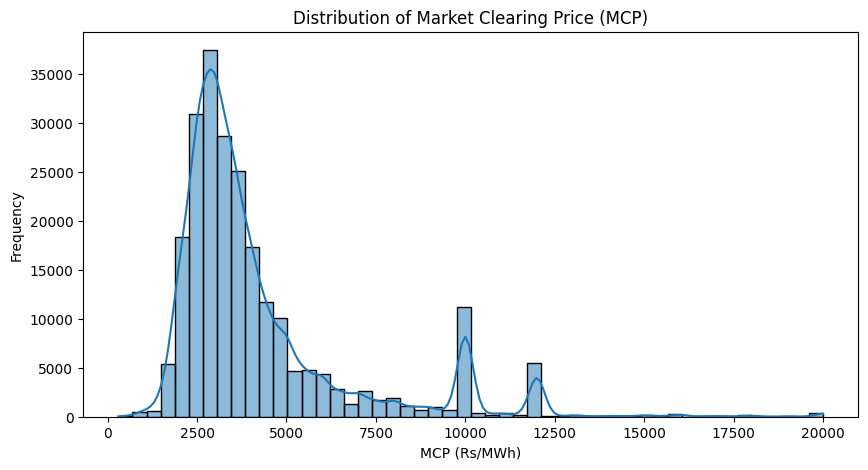

In [154]:
plt.figure(figsize=(10,5))

sns.histplot(df['MCP (Rs/MWh) *'], bins=50, kde=True)

plt.title('Distribution of Market Clearing Price (MCP)')
plt.xlabel('MCP (Rs/MWh)')
plt.ylabel('Frequency')

plt.show()

In [155]:
plt.savefig('time_series_plot.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

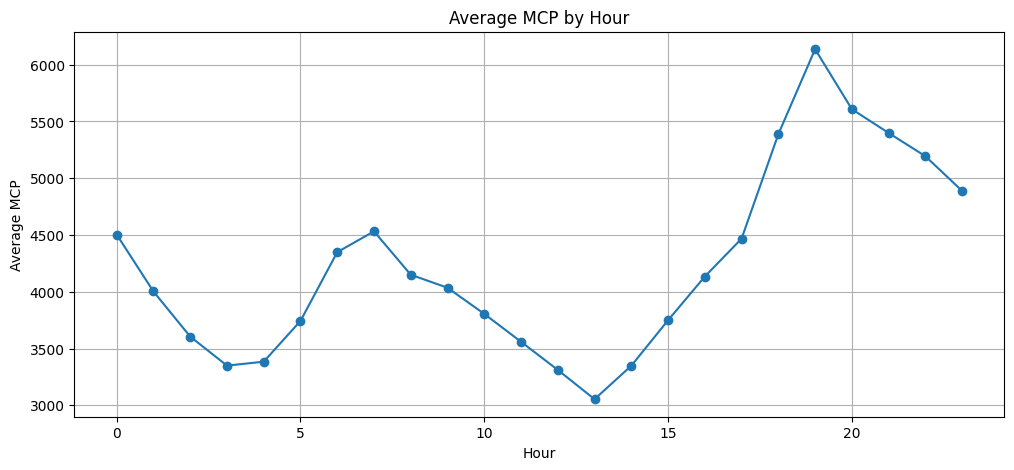

In [156]:
hourly_price = df.groupby('Hour')['MCP (Rs/MWh) *'].mean()

plt.figure(figsize=(12,5))

hourly_price.plot(marker='o')

plt.title('Average MCP by Hour')
plt.xlabel('Hour')
plt.ylabel('Average MCP')

plt.grid(True)

plt.show()

In [157]:
plt.savefig('hourly_trend.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

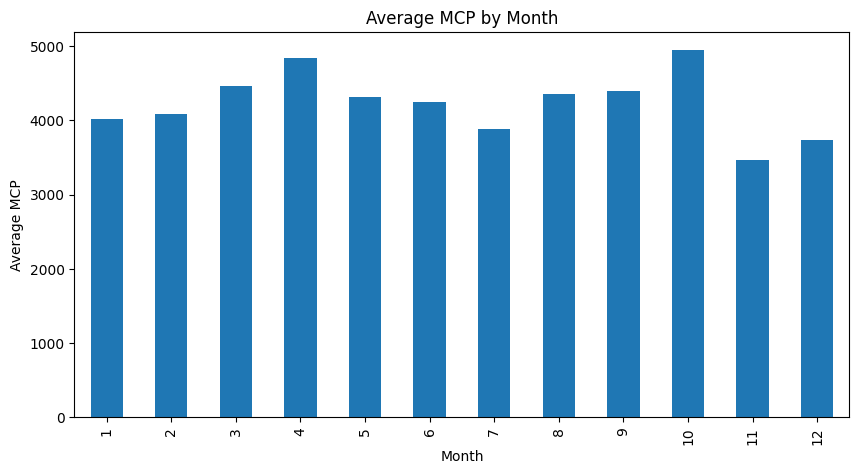

In [158]:
monthly_price = df.groupby('Month')['MCP (Rs/MWh) *'].mean()

plt.figure(figsize=(10,5))

monthly_price.plot(kind='bar')

plt.title('Average MCP by Month')
plt.xlabel('Month')
plt.ylabel('Average MCP')

plt.show()

In [159]:
plt.savefig('monthly_trend.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

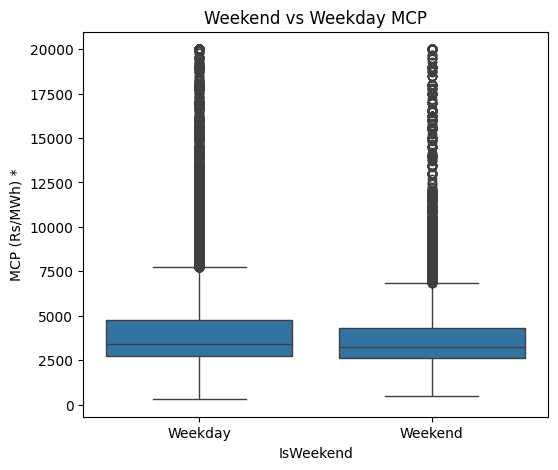

In [160]:
plt.figure(figsize=(6,5))

sns.boxplot(x='IsWeekend', y='MCP (Rs/MWh) *', data=df)

plt.xticks([0,1], ['Weekday','Weekend'])

plt.title('Weekend vs Weekday MCP')

plt.show()

In [161]:
plt.savefig('weekend_vs_weekday.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

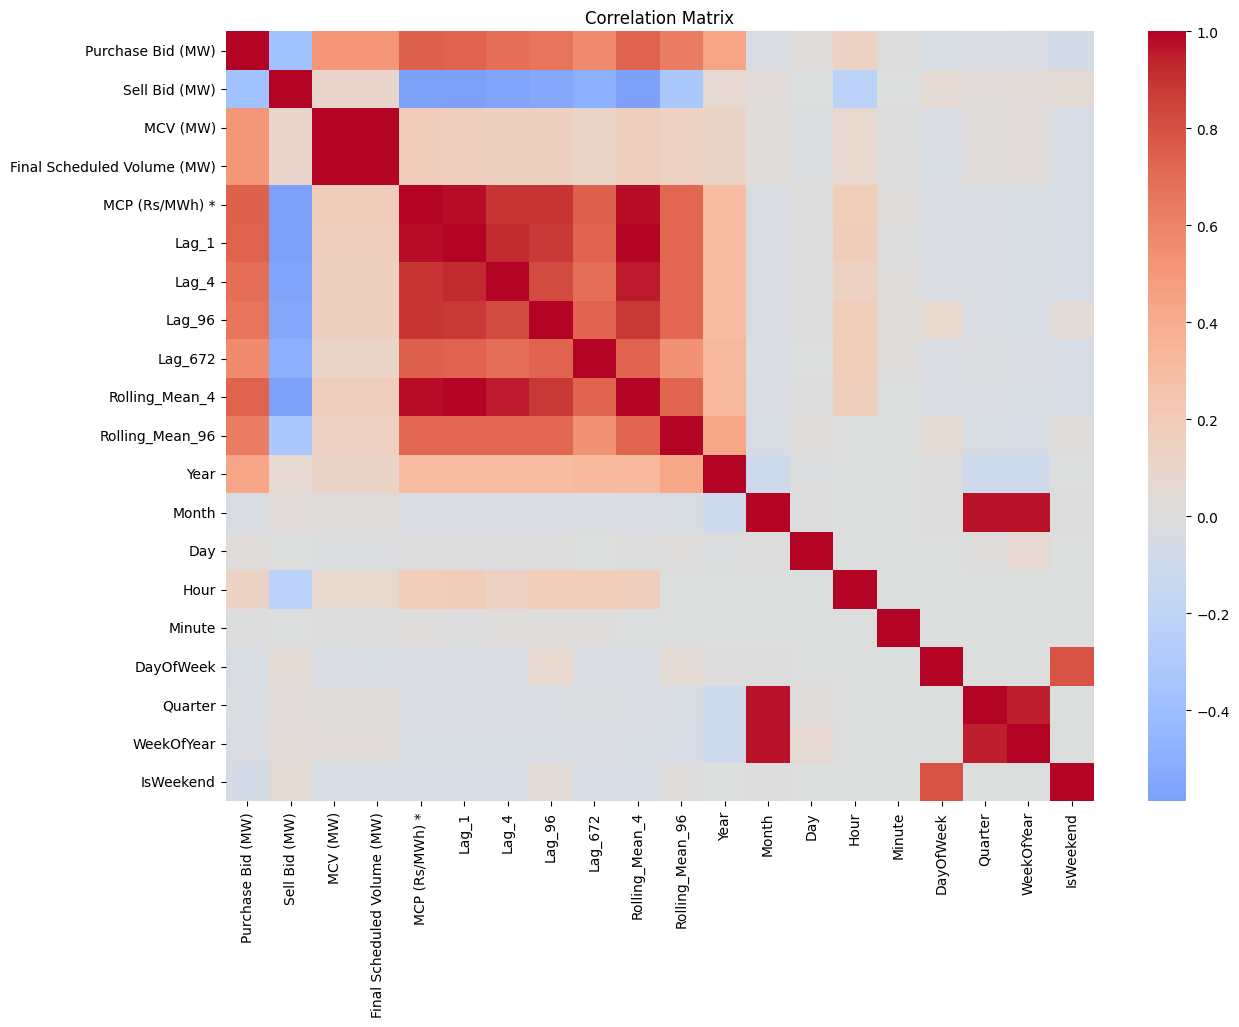

In [162]:
plt.figure(figsize=(14,10))

corr = df.drop(columns=['TimeStamp']).corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')

plt.show()

In [163]:
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

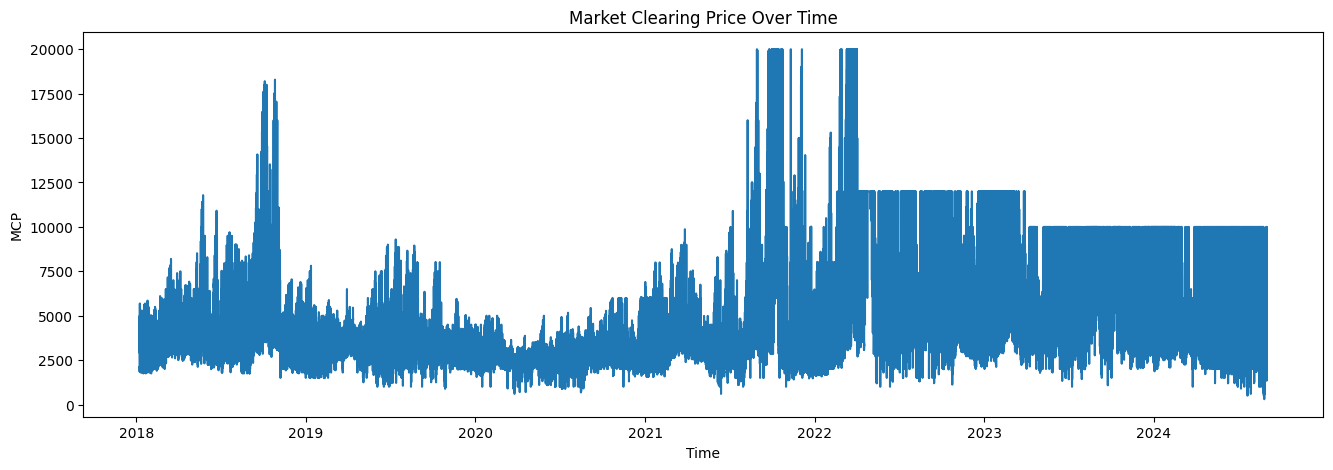

In [164]:
plt.figure(figsize=(16,5))

plt.plot(df['TimeStamp'], df['MCP (Rs/MWh) *'])

plt.title('Market Clearing Price Over Time')

plt.xlabel('Time')
plt.ylabel('MCP')

plt.show()

In [165]:
plt.savefig('distribution_mcp.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [166]:
#  Model Building

In [167]:
# Target
y = df['MCP (Rs/MWh) *']

# Features
X = df.drop(columns=['TimeStamp', 'MCP (Rs/MWh) *'])

In [168]:
print(X.shape)
print(y.shape)

(233088, 19)
(233088,)


In [169]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [170]:
print(X_train.shape)
print(X_test.shape)

(186470, 19)
(46618, 19)


In [171]:
# Model Training

In [172]:
# Linear Regression - Importing required libraries

In [173]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [174]:
# scaling the features

In [175]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [176]:
# Training the model

In [177]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

LinearRegression()

In [178]:
# Predictions

In [179]:
y_pred_lr = lr.predict(X_test_scaled)

In [180]:
# Evaluation

In [181]:
mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Results
-------------------------
MAE  : 247.39
RMSE : 466.43
R²   : 0.9717


In [182]:
# Actual vs Predicted Plot

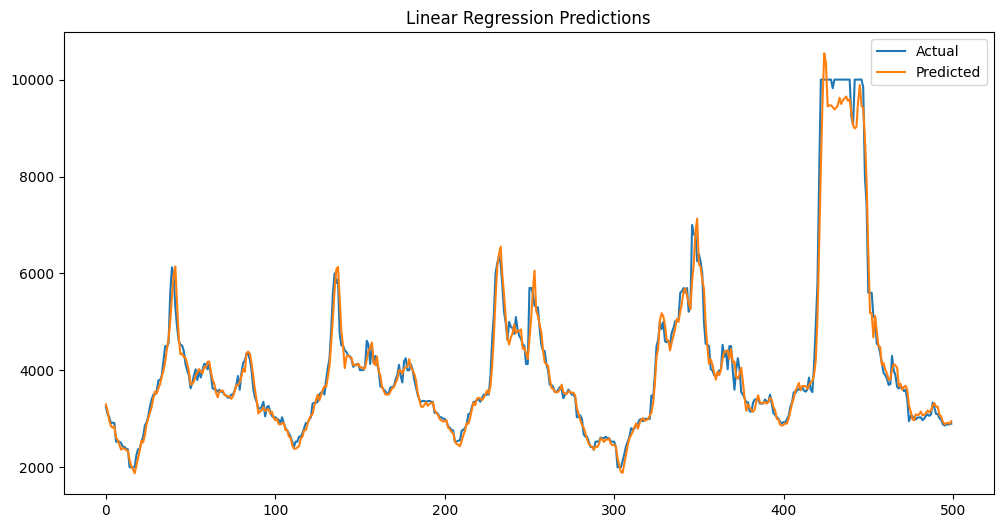

In [183]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:500], label='Actual')

plt.plot(y_pred_lr[:500], label='Predicted')

plt.legend()

plt.title("Linear Regression Predictions")

plt.show()

In [184]:
plt.savefig('linear_regression_prediction.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [185]:
##  Random Forest Regressor

In [ ]:
## Model Optimization

Initially, the Random Forest model generated a `.pkl` file of approximately **1.56 GB**, making it unsuitable for deployment.

To improve deployment efficiency, I optimized the model by tuning the following hyperparameters:

- n_estimators = 50
- max_depth = 20
- min_samples_leaf = 5

This reduced the model size to approximately **100 MB** while also improving the model's performance.

Final Results:
- MAE: 188.65
- RMSE: 379.22
- R² Score: 0.9813

In [186]:
## Importing the model

In [187]:
from sklearn.ensemble import RandomForestRegressor

In [188]:
## model creation

In [220]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=5, n_estimators=50,
                      n_jobs=-1, random_state=42)

In [190]:
## model training

In [191]:
rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [192]:
## predictions

In [227]:
y_pred_rf = rf.predict(X_test)

In [194]:
## Model Evaluation

In [228]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("----------------------")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Results
----------------------
MAE  : 188.65
RMSE : 379.22
R²   : 0.9813


In [229]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,Lag_1,0.965048
8,Rolling_Mean_4,0.014760
5,Lag_4,0.008518
6,Lag_96,0.003208
0,Purchase Bid (MW),0.001421
9,Rolling_Mean_96,0.001297
1,Sell Bid (MW),0.001063
7,Lag_672,0.000882
14,Minute,0.000762
13,Hour,0.000696


In [197]:
## Model Comparison

In [198]:
## Creating a data frame ## comparison table

In [230]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        round(mae,2),
        round(rf_mae,2),
        round(xgb_mae,2)
    ],
    "RMSE": [
        round(rmse,2),
        round(rf_rmse,2),
        round(xgb_rmse,2)
    ],
    "R² Score": [
        round(r2,4),
        round(rf_r2,4),
        round(xgb_r2,4)
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,247.39,466.43,0.9717
1,Random Forest,188.65,379.22,0.9813
2,XGBoost,210.32,390.06,0.9802


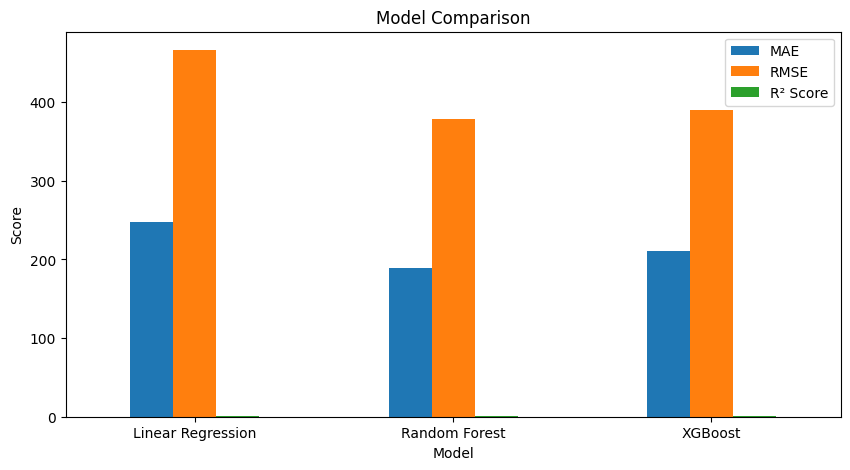

In [231]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

In [232]:
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [204]:
## XGBoost Regressor

In [200]:
from xgboost import XGBRegressor

In [203]:
## Model Creation

In [201]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [202]:
## Model Training

In [205]:
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [206]:
## Prediction

In [207]:
y_pred_xgb = xgb.predict(X_test)

In [208]:
##  Model Evaluation

In [209]:
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Results
----------------
MAE  : 210.32
RMSE : 390.06
R²   : 0.9802


In [210]:
# Saving the Best Model

In [211]:
import joblib

In [212]:
## selected Random Forest as Best Model based on the scores

In [216]:
joblib.dump(rf, "electricity_price_model.pkl")

['electricity_price_model.pkl']

In [217]:
import os

os.listdir()

['.config',
 'linear_regression_prediction.png',
 'DAM.xlsx',
 'model_comparison.png',
 'electricity_price_model.pkl',
 'correlation_heatmap.png',
 'monthly_trend.png',
 'hourly_trend.png',
 'weekend_vs_weekday.png',
 'distribution_mcp.png',
 'time_series_plot.png',
 'sample_data']

In [222]:
import joblib

joblib.dump(rf, "electricity_price_model.pkl")

['electricity_price_model.pkl']

In [233]:
X_train.columns.tolist()

['Purchase Bid (MW)',
 'Sell Bid (MW)',
 'MCV (MW)',
 'Final Scheduled Volume (MW)',
 'Lag_1',
 'Lag_4',
 'Lag_96',
 'Lag_672',
 'Rolling_Mean_4',
 'Rolling_Mean_96',
 'Year',
 'Month',
 'Day',
 'Hour',
 'Minute',
 'DayOfWeek',
 'Quarter',
 'WeekOfYear',
 'IsWeekend']